In [1]:
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands, plot_time_bands_median, Graphs, load_all_pickles
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
train_info = GraphsTraining()
import ast
import re

### Load JAX results

In [2]:
results_jax_seeds = load_all_pickles("results/jax_rl_reg_study", recursive=False)
r_seeds_jax = results_jax_seeds[1]
r_seeds_jax_no_logs = results_jax_seeds[0]

Loaded results/jax_rl_reg_study/results_NO_logging.pkl
Loaded results/jax_rl_reg_study/results_WITH_logging.pkl

Loaded 2 files from results/jax_rl_reg_study


In [3]:
r_seeds_jax

{(('[7, 64, 1]', 10, 10000),
  '2015-01-15',
  3998156390): [([2.4041458214083646,
    2.3434108656636075,
    2.345670167231282,
    2.345612859759507,
    2.3456218876813124,
    2.3456211830752407,
    2.3456211803022753,
    2.3456211775265943,
    2.3456211775265943,
    2.3456211775265943,
    2.3456211775265943,
    2.3456211803022926,
    2.3456211775265943,
    2.3456211775265943,
    2.3456211775265943,
    2.3456211775265943,
    2.3456211775265943,
    2.3456211775265943,
    2.3456211775265943,
    2.3456211803022926,
    2.3456211775265943,
    2.3456211803022926,
    2.3456211775265943,
    2.3456211775265943,
    2.345621178488309,
    2.345621177526592,
    2.3456211775266262,
    2.3456211775269566,
    2.3456212044238787,
    2.345621277198757,
    2.3456211930350563,
    2.3456212428913092,
    2.3456211811432626,
    2.3456211793391573,
    2.3456211810958614,
    2.345621180266859,
    2.3456211962125475,
    2.3456212016052747,
    2.3456211857326936,
    2.34561

In [4]:
def format_jax(path):
    r_no_logs, r_w_logs = load_all_pickles(path, recursive=False)

    df_no_logs = (
        pd.DataFrame(r_no_logs).T
        .reset_index()
        .rename(columns={"level_0": "params", "level_1": "date", "level_2": "seed"})
    )
    del r_w_logs["training_losses"]
    df_w_logs = (
        pd.DataFrame(r_w_logs).T
        .reset_index()
    )
    
    if len(df_w_logs[0].iloc[0][0]) == 0:
        df_w_logs = df_w_logs.rename(
                columns={
                    "level_0": "params",
                    "level_1": "date",
                    "level_2": "seed",
                    0: "times_elapsed",
                    1: "training_losses",
                }
            )
    else:
        df_w_logs = df_w_logs.rename(
                columns={
                    "level_0": "params",
                    "level_1": "date",
                    "level_2": "seed",
                    0: "training_losses",
                }
            )        

    # Overwrite times with the no-log timings
    df_w_logs["times_elapsed"] = df_no_logs["times_elapsed"].values

    df_w_logs["penalty"] = df_w_logs["params"].apply(lambda x: x[1])
    df_w_logs["n_epochs"] = df_w_logs["params"].apply(lambda x: x[2])
    df_w_logs["mse_train_log"] = df_w_logs["training_losses"].apply(lambda x: x[0])
    df_w_logs["mse_test_log"]  = df_w_logs["training_losses"].apply(lambda x: x[1])
    df_w_logs["n_records"] = df_w_logs["mse_train_log"].apply(len)
    df_w_logs["t_per_segment"] = df_w_logs["times_elapsed"] / df_w_logs["n_records"]

    df_tmp = df_w_logs.assign(
        epoch_logs=lambda d: d.apply(
            lambda r: [((i + 1) * r["t_per_segment"], vt, vs, i * r["n_records"])
                       for i, (vt, vs) in enumerate(zip(r["mse_train_log"], r["mse_test_log"]))],
            axis=1,
        )
    )

    long = (
        df_tmp
        .explode("epoch_logs")
        .assign(
            time=lambda d: d["epoch_logs"].str[0],
            mse_train_log=lambda d: d["epoch_logs"].str[1],
            mse_test_log=lambda d: d["epoch_logs"].str[2],
            n_epochs_ =lambda d: d["epoch_logs"].str[2],
        )
        .drop(columns=["epoch_logs", "training_losses", "params", "times_elapsed", "n_epochs", "n_records"])
        .reset_index(drop=True)
    )

    return long

# different seeds
df_results_seeds = format_jax("results/jax_rl_reg_study")

Loaded results/jax_rl_reg_study/results_NO_logging.pkl
Loaded results/jax_rl_reg_study/results_WITH_logging.pkl

Loaded 2 files from results/jax_rl_reg_study


In [5]:
df_results_seeds

,date,seed,penalty,mse_train_log,mse_test_log,t_per_segment,time,n_epochs_
0,2015-01-15,3998156390,10.0,2.404146,5.137105,0.087397,0.087397,5.137105
1,2015-01-15,3998156390,10.0,2.343411,4.987639,0.087397,0.174794,4.987639
2,2015-01-15,3998156390,10.0,2.345670,4.988334,0.087397,0.262191,4.988334
3,2015-01-15,3998156390,10.0,2.345613,4.988289,0.087397,0.349588,4.988289
4,2015-01-15,3998156390,10.0,2.345622,4.988296,0.087397,0.436985,4.988296
...,...,...,...,...,...,...,...,...
30145,2015-01-15,686232320,0.0,0.003309,0.107046,0.417524,82.252271,0.107046
30146,2015-01-15,686232320,0.0,0.002978,0.106284,0.417524,82.669796,0.106284
30147,2015-01-15,686232320,0.0,0.002968,0.106188,0.417524,83.087320,0.106188
30148,2015-01-15,686232320,0.0,0.003137,0.105961,0.417524,83.504844,0.105961


### Load Pyomo results

In [6]:
def results_to_df(results: dict) -> pd.DataFrame:
    rows = []
    for (cfg, date, seed), vals in results.items():
        layer_sizes, penalty, tol = cfg  # cfg is the first tuple element
        r = vals.get("result", {})
        rows.append(
            {
                "layer_sizes": layer_sizes,
                "penalty": penalty,
                "tol": tol,
                "date": date,
                "seed": seed,
                "solver_time": r.get("solver_time"),
                "termination": getattr(r.get("termination_condition"), "value", r.get("termination_condition")),
                "message": r.get("message"),
                "times_elapsed": vals.get("times_elapsed"),
                "mse_odeint": vals.get("mse_odeint"),
                "mse_coll_ode": vals.get("mse_coll_ode"),
                "mse_odeint_test": vals.get("mse_odeint_test"),
                "mse_coll_ode_test": vals.get("mse_coll_ode_test"),
            }
        )
    return pd.DataFrame(rows)

In [7]:
results_pyomo = load_all_pickles("results/pyomo_rl_reg_study", recursive=False)[0]
pyomo_df_seeds = results_to_df(results_pyomo)

Loaded results/pyomo_rl_reg_study/results_full.pkl

Loaded 1 files from results/pyomo_rl_reg_study


### Comparison

In [8]:
jax_df = df_results_seeds.copy()
pyomo_df = pyomo_df_seeds.copy()

In [9]:
pyomo_df

,layer_sizes,penalty,tol,date,seed,solver_time,termination,message,times_elapsed,mse_odeint,mse_coll_ode,mse_odeint_test,mse_coll_ode_test
0,"[7, 64, 1]",10.0,0.000001,2015-01-15,4148974351,0.747860,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,0.747860,1.855578,1.855578,3.796163,3.796163
1,"[7, 64, 1]",10.0,0.000001,2015-01-15,865791434,0.734355,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,0.734355,1.855578,1.855578,3.796163,3.796163
2,"[7, 64, 1]",10.0,0.000001,2015-01-15,4289153135,0.734631,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,0.734631,1.855578,1.855578,3.796163,3.796163
3,"[7, 64, 1]",10.0,0.000001,2015-01-15,1871982174,0.764641,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,0.764641,1.855578,1.855578,3.796163,3.796163
4,"[7, 64, 1]",10.0,0.000001,2015-01-15,4165347232,0.743031,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,0.743031,1.855578,1.855578,3.796163,3.796163
...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,"[7, 64, 1]",0.0,0.000001,2015-01-15,2947823181,50.594936,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,50.594936,0.018147,0.000033,0.315701,0.242616
134,"[7, 64, 1]",0.0,0.000001,2015-01-15,508623825,39.482229,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,39.482229,0.014153,0.000050,0.624736,0.514085
135,"[7, 64, 1]",0.0,0.000001,2015-01-15,4289153135,25.965259,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,25.965259,0.245119,0.000027,1.300004,1.000035
136,"[7, 64, 1]",0.0,0.000001,2015-01-15,1871982174,32.254877,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,32.254877,0.033104,0.000018,1.269059,1.327169


In [10]:
def extract_hidden_width(x):
    """Middle width from [in, hidden, out], works for list or string like '[7, 128, 1]'."""
    if isinstance(x, (list, tuple, np.ndarray)):
        return int(x[1])
    s = str(x)
    try:
        v = ast.literal_eval(s)
        if isinstance(v, (list, tuple)) and len(v) > 1:
            return int(v[1])
    except Exception:
        pass
    nums = re.findall(r"-?\d+", s)
    return int(nums[1]) if len(nums) > 1 else np.nan

def seed_rank_within_width(df, param_col, seed_col="seed"):
    """Map distinct seeds to 1..n within each width (sorted for stability)."""
    def _rank(s):
        uniq = sorted(pd.unique(s.dropna()))
        mapping = {v: i + 1 for i, v in enumerate(uniq)}
        return s.map(mapping).astype("Int64")
    return df.assign(seed_rank=df.groupby(param_col)[seed_col].transform(_rank))

# --- 1) prepare pyomo targets (every run, not mean) ---
py = (
    pyomo_df.copy()
    .reset_index()
    .rename(columns={"index": "pyomo_row", "times_elapsed": "pyomo_time"})
)
py["layer_width"] = py["layer_sizes"].apply(extract_hidden_width).astype("Int64")

# --- 2) prepare diffrax runs ---
dx = (
    jax_df.copy()
    .reset_index()
    .rename(columns={"index": "diffrax_row"})
)

# --- 3) overwrite seeds by rank (1..n) within each penalty, separately ---
py = seed_rank_within_width(py, param_col="penalty", seed_col="seed")
dx = seed_rank_within_width(dx, param_col="penalty", seed_col="seed")

# --- 4) merge on (penalty, seed_rank) and pick closest diffrax time per pyomo run ---
merged = py.merge(
    dx,
    on=["penalty", "seed_rank"],
    how="inner",
    suffixes=("_pyomo", "_diffrax"),
)

merged["time_diff"] = (merged["time"] - merged["pyomo_time"]).abs()

best = merged.loc[merged.groupby("pyomo_row")["time_diff"].idxmin()].copy()
best = best.sort_values("pyomo_row")  # preserve pyomo run order

# --- 5) recover slices ---
pyomo_df_rows = pyomo_df.loc[best["pyomo_row"].to_numpy()].copy()
jax_df_rows   = jax_df.loc[best["diffrax_row"].to_numpy()].copy()

# (optional) attach pairing info to jax_df_rows for plotting / debugging
jax_df_rows = jax_df_rows.assign(
    pyomo_timing=best["pyomo_time"].to_numpy(),
    time_diff=best["time_diff"].to_numpy(),
    seed_rank=best["seed_rank"].to_numpy(),
    n_neurons=best["penalty"].to_numpy(),
)


In [11]:
pyomo_df.head(1)

,layer_sizes,penalty,tol,date,seed,solver_time,termination,message,times_elapsed,mse_odeint,mse_coll_ode,mse_odeint_test,mse_coll_ode_test
0,"[7, 64, 1]",10.0,0.000001,2015-01-15,4148974351,0.74786,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,0.74786,1.855578,1.855578,3.796163,3.796163


In [12]:
jax_df_rows.head(1)

,date,seed,penalty,mse_train_log,mse_test_log,t_per_segment,time,n_epochs_,pyomo_timing,time_diff,seed_rank,n_neurons
812,2015-01-15,923070472,10.0,2.345621,4.988296,0.087672,0.78905,4.988296,0.74786,0.04119,3,10.0


In [13]:
jax_train = Results.prep_for_boxplots(jax_df_rows,  'penalty',  'mse_train_log')
pyomo_train = Results.prep_for_boxplots(pyomo_df,  'penalty',  'mse_coll_ode')

jax_test = Results.prep_for_boxplots(jax_df_rows,  'penalty',  'mse_test_log')
pyomo_test = Results.prep_for_boxplots(pyomo_df,  'penalty',  'mse_coll_ode_test')

jax_times = Results.prep_for_boxplots(jax_df_rows,  'penalty',  'time')
pyomo_times = Results.prep_for_boxplots(pyomo_df,  'penalty',  'times_elapsed')

In [14]:
exponents = range(-7, 2)
x_ticklabels = ["No reg"] + [fr"$10^{{{p}}}$" for p in exponents]

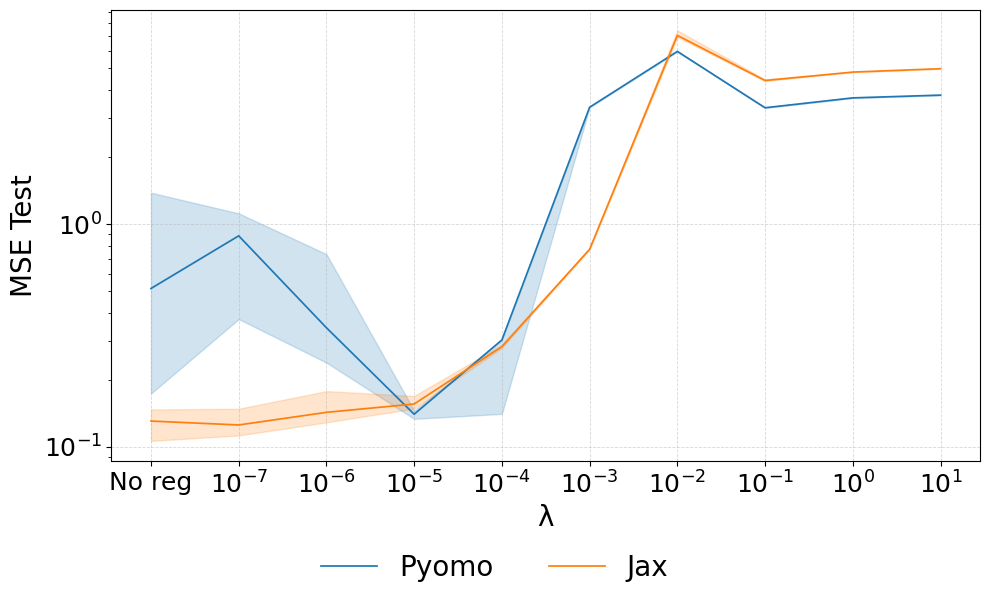

<Axes: xlabel='λ', ylabel='MSE Test'>

In [15]:
Graphs.plot_lines_ci_from_lists(
    pyomo_test["mse_coll_ode_test"],
    jax_test["mse_test_log"],
    pyomo_train.x_labels,
    title="",
    ylabel="MSE Test",
    color_labels=("Pyomo", "Jax"),
    x_label="λ",
    figsize=(10, 6),
    label_fontsize=20,
    tick_fontsize=18,
    legend_fontsize=20,
    title_fontsize=20,
    legend_bbox_y=-0.02,
    legend_ncol=2,
    ci=(10,90),
    alpha_band=0.2,
    line_width=1.25,
    x_ticklabels=x_ticklabels,
    y_log=True,               # default; keeps 10^k ticks
    y_log_locator_base=10,    # default; uses LogLocator
    y_log_mathtext=True,      # default; renders 10^k
)


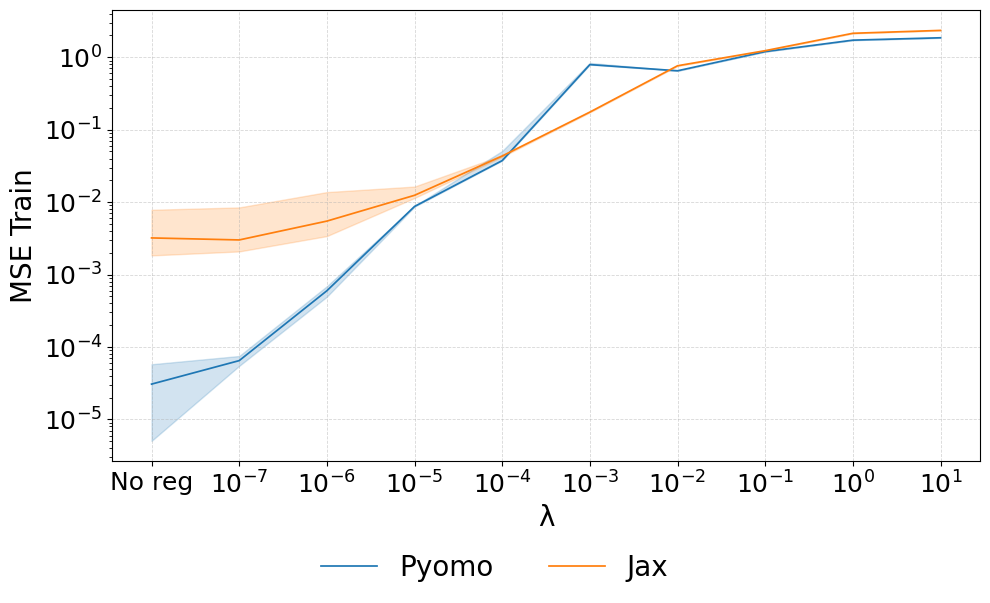

<Axes: xlabel='λ', ylabel='MSE Train'>

In [16]:
Graphs.plot_lines_ci_from_lists(
    pyomo_train["mse_coll_ode"],
    jax_train["mse_train_log"],
    pyomo_train.x_labels,
    title="",
    ylabel="MSE Train",
    color_labels=("Pyomo", "Jax"),
    x_label="λ",
    figsize=(10, 6),
    label_fontsize=20,
    tick_fontsize=18,
    legend_fontsize=20,
    title_fontsize=20,
    legend_bbox_y=-0.02,
    legend_ncol=2,
    ci=(10, 90),
    alpha_band=0.2,
    line_width=1.25,
    x_ticklabels=x_ticklabels,
    y_log=True,               # default; keeps 10^k ticks
    y_log_locator_base=10,    # default; uses LogLocator
    y_log_mathtext=True,      # default; renders 10^k
)


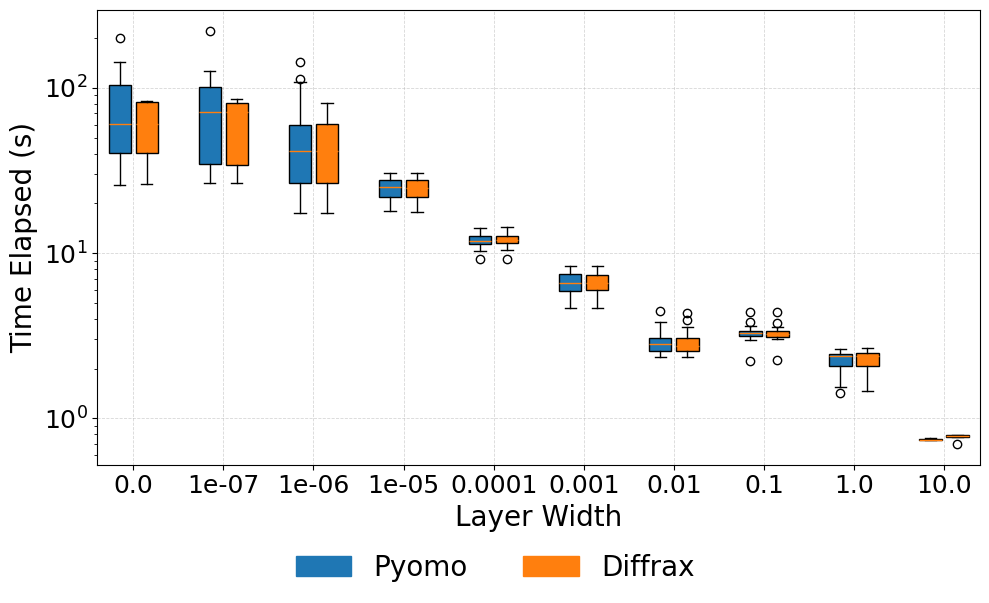

<Axes: xlabel='Layer Width', ylabel='Time Elapsed (s)'>

In [17]:
Graphs.plot_boxplots_custom(pyomo_times['times_elapsed'], jax_times['time'], pyomo_train.x_labels, 
            '',     
              'Time Elapsed (s)', color_labels=["Pyomo", "Diffrax"],
              x_label = "Layer Width",
              figsize=(10, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              y_log = True
              )

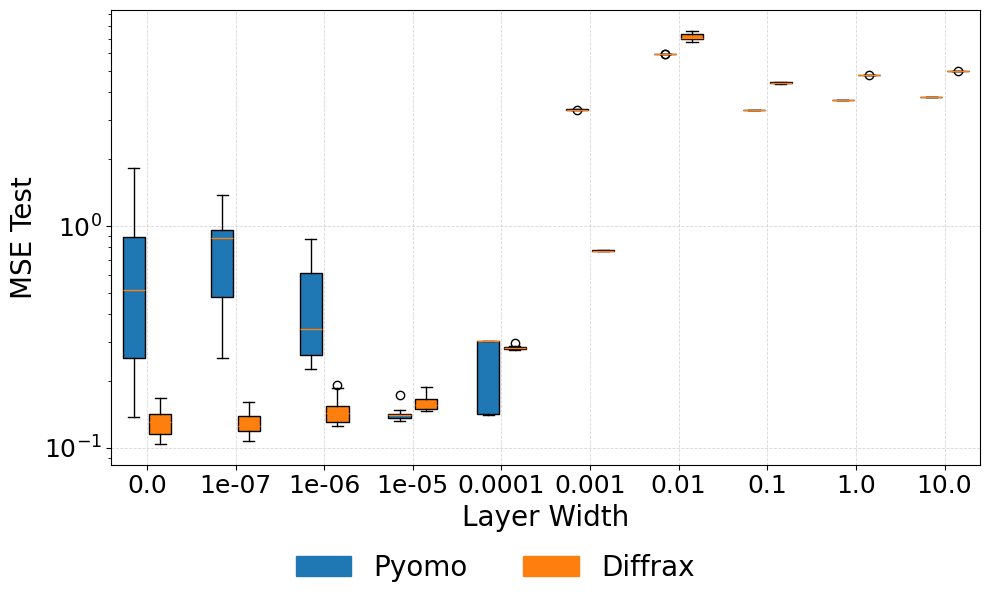

<Axes: xlabel='Layer Width', ylabel='MSE Test'>

In [18]:
Graphs.plot_boxplots_custom(pyomo_test['mse_coll_ode_test'], jax_test['mse_test_log'], pyomo_train.x_labels, 
            '',     
              'MSE Test', color_labels=["Pyomo", "Diffrax"],
              x_label = "Layer Width",
              figsize=(10, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              )

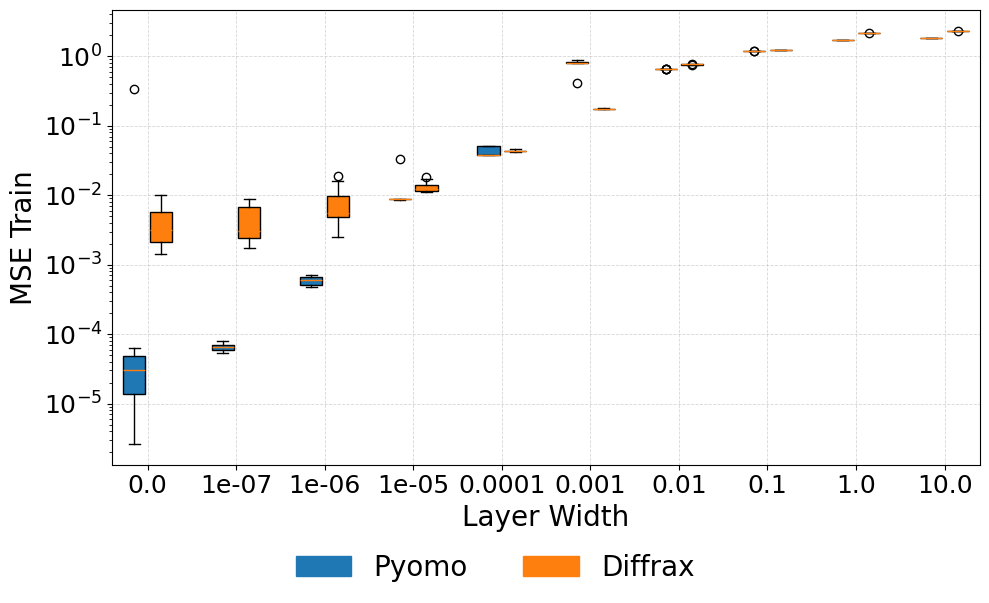

<Axes: xlabel='Layer Width', ylabel='MSE Train'>

In [19]:
Graphs.plot_boxplots_custom(pyomo_train['mse_coll_ode'], jax_train['mse_train_log'], pyomo_train.x_labels, 
            '',     
              'MSE Train', color_labels=["Pyomo", "Diffrax"],
              x_label = "Layer Width",
              figsize=(10, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              )

In [20]:
from __future__ import annotations

from dataclasses import dataclass
from math import sqrt
from typing import Iterable, Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -------------------------
# 1) Aggregation (mean + 95% CI)
# -------------------------

def _as_tuple(x):
    """Convert list-like layer_sizes to tuple so it can be grouped reliably."""
    if isinstance(x, (list, tuple, np.ndarray)):
        return tuple(x)
    return x

def _ci95(series: pd.Series) -> tuple[float, float]:
    """95% CI for the mean using normal approx (1.96 * s/sqrt(n))."""
    s = pd.to_numeric(series, errors="coerce").dropna()
    n = int(s.shape[0])
    if n <= 1:
        return (np.nan, np.nan)
    mean = float(s.mean())
    std = float(s.std(ddof=1))
    half = 1.96 * std / sqrt(n)
    return (mean - half, mean + half)

def aggregate_sweep(
    df: pd.DataFrame,
    metrics: Sequence[str],
    group_cols: Optional[Sequence[str]] = None,
) -> pd.DataFrame:
    """
    Aggregate repeated runs across seeds for each (layer_sizes, penalty, tol[, date]) point.

    Returns columns:
      <metric>_mean, <metric>_ci_lo, <metric>_ci_hi, n_runs
    """
    if df.empty:
        return df.copy()

    df = df.copy()
    df["layer_sizes"] = df["layer_sizes"].apply(_as_tuple)

    # Default grouping: include date only if it exists and varies
    if group_cols is None:
        group_cols = ["layer_sizes", "penalty", "tol"]
        if "date" in df.columns and df["date"].nunique(dropna=False) > 1:
            group_cols = list(group_cols) + ["date"]

    # Keep only relevant cols
    keep = list(dict.fromkeys(list(group_cols) + list(metrics)))
    if "seed" in df.columns:
        keep.append("seed")
    df = df[keep]

    # Drop rows that have all metrics missing
    df = df.dropna(subset=list(metrics), how="all")
    if df.empty:
        return df

    agg_dict = {}
    for m in metrics:
        agg_dict[f"{m}_mean"] = (m, "mean")
        agg_dict[f"{m}_ci"] = (m, _ci95)

    # n_runs = number of rows contributing (across seeds)
    agg_df = (
        df.groupby(list(group_cols), dropna=False)
          .agg(**agg_dict, n_runs=(metrics[0], "count"))
          .reset_index()
    )

    # split CI tuple into lo/hi columns
    for m in metrics:
        ci_col = f"{m}_ci"
        lohi = agg_df[ci_col].apply(lambda t: t if isinstance(t, (tuple, list)) and len(t) == 2 else (np.nan, np.nan))
        agg_df[[f"{m}_ci_lo", f"{m}_ci_hi"]] = pd.DataFrame(lohi.tolist(), index=agg_df.index)
        agg_df = agg_df.drop(columns=[ci_col])

        # if CI is NaN (n<=1), fall back to mean so plotting doesn’t drop the point
        mean_col = f"{m}_mean"
        agg_df[f"{m}_ci_lo"] = agg_df[f"{m}_ci_lo"].fillna(agg_df[mean_col])
        agg_df[f"{m}_ci_hi"] = agg_df[f"{m}_ci_hi"].fillna(agg_df[mean_col])

    return agg_df


# -------------------------
# 2) Plotting (line + shaded CI)
# -------------------------

def _format_layer_sizes(ls) -> str:
    if isinstance(ls, (tuple, list)):
        return "x".join(map(str, ls))
    return str(ls)

def plot_curve_ci(
    ax: plt.Axes,
    x: np.ndarray,
    y: np.ndarray,
    ylo: np.ndarray,
    yhi: np.ndarray,
    *,
    label: Optional[str] = None,
    show_points: bool = False,
):
    ax.plot(x, y, label=label)
    ax.fill_between(x, ylo, yhi, alpha=0.2)
    if show_points:
        ax.scatter(x, y, s=18)

@dataclass
class PlotFilters:
    tol: Optional[float] = None
    penalty: Optional[float] = None
    layer_sizes: Optional[Sequence[int]] = None
    date: Optional[str] = None
    min_runs: int = 3

def plot_sweep_line(
    agg_df: pd.DataFrame,
    *,
    metric: str,
    x_axis: str = "penalty",   # "penalty" | "tol" | "width"
    filters: PlotFilters = PlotFilters(),
    separate_by_width: bool = True,  # if x_axis is penalty/tol, plot per layer_sizes
    show_points: bool = False,
    title: Optional[str] = None,
):
    """
    Plot aggregated curves with CI bands.

    Notes:
    - penalty==0 cannot be shown on log-x; we automatically switch to symlog if zeros exist.
    """
    y_col  = f"{metric}_mean"
    lo_col = f"{metric}_ci_lo"
    hi_col = f"{metric}_ci_hi"
    for c in (y_col, lo_col, hi_col):
        if c not in agg_df.columns:
            raise ValueError(f"Missing column '{c}'. Did you aggregate metric '{metric}'?")

    df = agg_df.copy()

    # Apply filters
    if filters.date is not None and "date" in df.columns:
        df = df[df["date"].astype(str) == str(filters.date)]
    if filters.tol is not None and "tol" in df.columns and x_axis != "tol":
        df = df[df["tol"] == filters.tol]
    if filters.penalty is not None and "penalty" in df.columns and x_axis != "penalty":
        df = df[df["penalty"] == filters.penalty]
    if filters.layer_sizes is not None and "layer_sizes" in df.columns and x_axis != "width":
        df = df[df["layer_sizes"] == tuple(filters.layer_sizes)]

    # min runs
    if "n_runs" in df.columns:
        df = df[df["n_runs"] >= filters.min_runs]

    if df.empty:
        raise ValueError("No data left after filtering (check tol/penalty/layer_sizes/date/min_runs).")

    # Choose x
    if x_axis == "penalty":
        x_col = "penalty"
        xlabel = "regularization (penalty)"
    elif x_axis == "tol":
        x_col = "tol"
        xlabel = "tolerance (tol)"
    elif x_axis == "width":
        x_col = "layer_sizes"
        xlabel = "layer_sizes"
    else:
        raise ValueError("x_axis must be one of: 'penalty', 'tol', 'width'")

    # Decide scales
    is_time_like = any(k in metric.lower() for k in ["time", "elapsed", "solver"])
    yscale = "linear" if is_time_like else "log"

    fig, ax = plt.subplots(figsize=(10, 6))

    if x_axis == "width":
        # plot width on categorical positions
        df = df.sort_values("layer_sizes")
        x_vals = np.arange(len(df))
        plot_curve_ci(
            ax,
            x_vals,
            df[y_col].to_numpy(),
            df[lo_col].to_numpy(),
            df[hi_col].to_numpy(),
            label=None,
            show_points=show_points,
        )
        ax.set_xticks(x_vals)
        ax.set_xticklabels([_format_layer_sizes(v) for v in df["layer_sizes"]], rotation=20, ha="right")
        ax.set_xscale("linear")
    else:
        # optionally multiple curves by layer_sizes
        if separate_by_width and "layer_sizes" in df.columns and df["layer_sizes"].nunique() > 1:
            for ls, g in df.groupby("layer_sizes"):
                g = g.sort_values(x_col)
                plot_curve_ci(
                    ax,
                    g[x_col].to_numpy(),
                    g[y_col].to_numpy(),
                    g[lo_col].to_numpy(),
                    g[hi_col].to_numpy(),
                    label=f"lw={_format_layer_sizes(ls)}",
                    show_points=show_points,
                )
            ax.legend()
        else:
            df = df.sort_values(x_col)
            plot_curve_ci(
                ax,
                df[x_col].to_numpy(),
                df[y_col].to_numpy(),
                df[lo_col].to_numpy(),
                df[hi_col].to_numpy(),
                label=None,
                show_points=show_points,
            )

        # x scale: log unless zeros exist -> symlog
        x_vals = df[x_col].to_numpy()
        if np.any(pd.to_numeric(pd.Series(x_vals), errors="coerce").fillna(0).to_numpy() <= 0):
            ax.set_xscale("symlog", linthresh=1e-6)
        else:
            ax.set_xscale("log")

    ax.set_yscale(yscale)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(metric)
    ax.set_title(title or f"{metric} vs {x_axis}")
    fig.tight_layout()
    return fig, ax


In [21]:
pyomo_df_seeds

,layer_sizes,penalty,tol,date,seed,solver_time,termination,message,times_elapsed,mse_odeint,mse_coll_ode,mse_odeint_test,mse_coll_ode_test
0,"[7, 64, 1]",10.0,0.000001,2015-01-15,4148974351,0.747860,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,0.747860,1.855578,1.855578,3.796163,3.796163
1,"[7, 64, 1]",10.0,0.000001,2015-01-15,865791434,0.734355,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,0.734355,1.855578,1.855578,3.796163,3.796163
2,"[7, 64, 1]",10.0,0.000001,2015-01-15,4289153135,0.734631,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,0.734631,1.855578,1.855578,3.796163,3.796163
3,"[7, 64, 1]",10.0,0.000001,2015-01-15,1871982174,0.764641,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,0.764641,1.855578,1.855578,3.796163,3.796163
4,"[7, 64, 1]",10.0,0.000001,2015-01-15,4165347232,0.743031,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,0.743031,1.855578,1.855578,3.796163,3.796163
...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,"[7, 64, 1]",0.0,0.000001,2015-01-15,2947823181,50.594936,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,50.594936,0.018147,0.000033,0.315701,0.242616
134,"[7, 64, 1]",0.0,0.000001,2015-01-15,508623825,39.482229,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,39.482229,0.014153,0.000050,0.624736,0.514085
135,"[7, 64, 1]",0.0,0.000001,2015-01-15,4289153135,25.965259,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,25.965259,0.245119,0.000027,1.300004,1.000035
136,"[7, 64, 1]",0.0,0.000001,2015-01-15,1871982174,32.254877,optimal,Ipopt 3.14.19\x3a Optimal Solution Found,32.254877,0.033104,0.000018,1.269059,1.327169


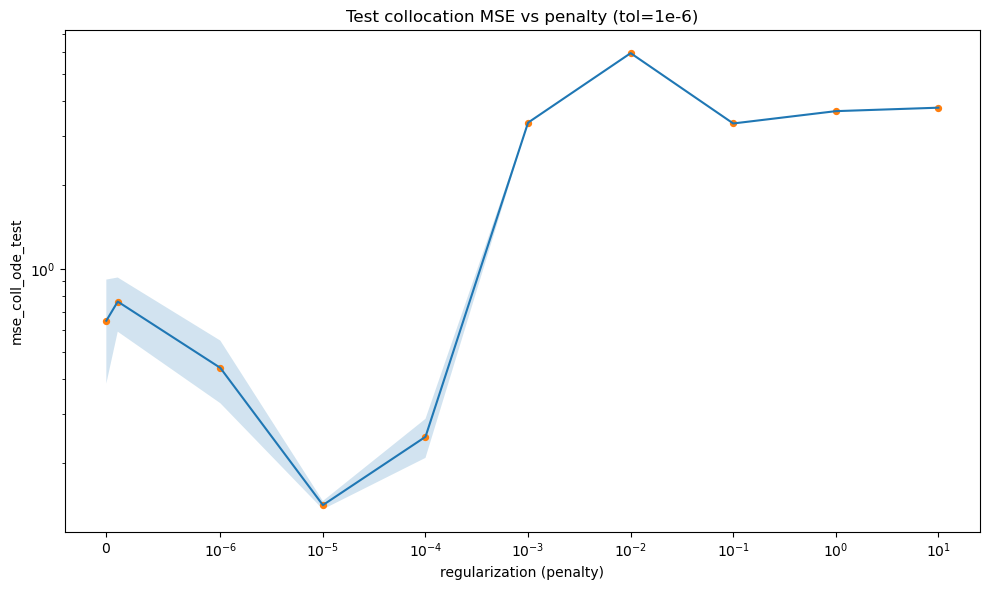

In [22]:
metrics = [
    "mse_odeint",
    "mse_coll_ode",
    "mse_odeint_test",
    "mse_coll_ode_test",
    "solver_time",        # or times_elapsed if that’s what you want
]

agg = aggregate_sweep(pyomo_df_seeds, metrics=metrics)

# Example 1: metric vs penalty (fix tol, plot one curve per layer_sizes)
fig, ax = plot_sweep_line(
    agg,
    metric="mse_coll_ode_test",
    x_axis="penalty",
    filters=PlotFilters(tol=1e-6, min_runs=3),
    separate_by_width=True,
    show_points=True,
    title="Test collocation MSE vs penalty (tol=1e-6)",
)
plt.show()




In [23]:
pyomo_df_seeds.groupby("penalty")["mse_coll_ode"].mean()

penalty
0.000000e+00    0.022911
1.000000e-07    0.000065
1.000000e-06    0.000594
1.000000e-05    0.010388
1.000000e-04    0.041862
1.000000e-03    0.789476
1.000000e-02    0.649865
1.000000e-01    1.195188
1.000000e+00    1.720895
1.000000e+01    1.855578
Name: mse_coll_ode, dtype: float64

In [24]:
pyomo_df_seeds.groupby("penalty")["mse_coll_ode_test"].mean()

penalty
0.000000e+00    0.650088
1.000000e-07    0.761590
1.000000e-06    0.439748
1.000000e-05    0.141098
1.000000e-04    0.248431
1.000000e-03    3.354141
1.000000e-02    5.964858
1.000000e-01    3.330980
1.000000e+00    3.688958
1.000000e+01    3.796163
Name: mse_coll_ode_test, dtype: float64

In [25]:
pyomo_train = Results.prep_for_boxplots(pyomo_df_seeds,  'penalty',  'mse_coll_ode_test')

In [26]:
pyomo_train

,mse_coll_ode_test,x_labels
0,"[0.27924399623367685, 1.819784753473613, 0.263...",0.000000e+00
1,"[0.25272732948786436, 0.9551946550585108, 0.36...",1.000000e-07
2,"[0.4568168236941012, 0.5200918527582487, 0.256...",1.000000e-06
3,"[0.13842341113175505, 0.13726406226407628, 0.1...",1.000000e-05
4,"[0.14038925180398074, 0.30192179462794083, 0.3...",1.000000e-04
5,"[3.3639093651618714, 3.348641768777455, 3.3639...",1.000000e-03
6,"[5.96485789830187, 5.9648578525330755, 5.96485...",1.000000e-02
7,"[3.3309800244683396, 3.3309800244647887, 3.330...",1.000000e-01
8,"[3.6889582447397027, 3.688958244739701, 3.6889...",1.000000e+00
9,"[3.7961634482158324, 3.7961634482158324, 3.796...",1.000000e+01


In [27]:
Graphs.plot_reg_curve_ci(pyomo_train, "penalty", "mse_coll_ode_test", title="Pyomo RL Regularization Study - Test MSE Coll ODE", ylabel="MSE Coll ODE Test", xlabel="Penalty")

TypeError: plot_reg_curve_ci() missing 1 required positional argument: 'y_hi'

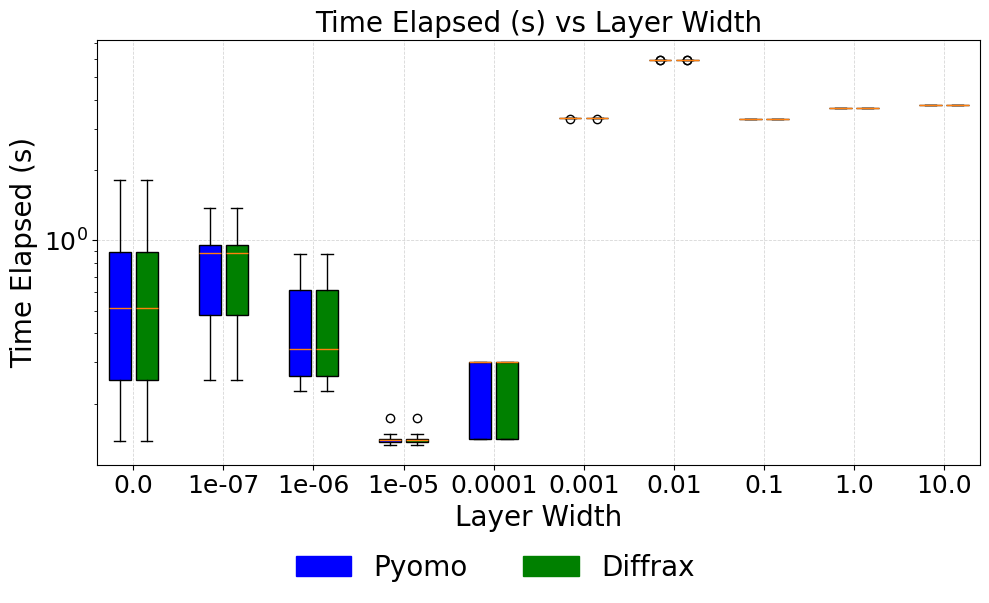

<Axes: title={'center': 'Time Elapsed (s) vs Layer Width'}, xlabel='Layer Width', ylabel='Time Elapsed (s)'>

In [13]:
Graphs.plot_boxplots_custom(pyomo_train['mse_coll_ode_test'], pyomo_train['mse_coll_ode_test'], pyomo_train.x_labels, 
            'Time Elapsed (s) vs Layer Width',     
              'Time Elapsed (s)', color_labels=["Pyomo", "Diffrax"],
              x_label = "Layer Width",
              figsize=(10, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              )